<a href="https://colab.research.google.com/github/ksw9179/AI_and_Data-/blob/main/%EA%B0%9C%EC%84%A0%EC%95%88_%5B%EC%8B%A4%EC%A0%84%5D_%EC%8B%A4%EC%A0%9C_%EC%95%94_%ED%99%98%EC%9E%90_%EC%9C%A0%EC%A0%84%EC%B2%B4_%EB%8D%B0%EC%9D%B4%ED%84%B0_%EB%8B%A4%EC%9A%B4%EB%A1%9C%EB%93%9C_%EB%B0%8F_%EC%98%88%ED%9B%84_%EC%98%88%EC%B8%A1_%EB%A8%B8%EC%8B%A0%EB%9F%AC%EB%8B%9D_%ED%8C%8C%EC%9D%B4%ED%94%84%EB%9D%BC%EC%9D%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =====================================================================
# [실전] 실제 암 환자 유전체 데이터 다운로드 및 예후 예측 머신러닝 파이프라인
# =====================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 그래프 스타일 설정
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Accent")

from sklearn.datasets import load_breast_cancer

print("🛰️ [1단계] Scikit-Learn 내장 실제 암(Breast Cancer) 유전체 및 임상 데이터셋 로드 중...")

# 사이킷런 내장 데이터셋으로 외부 다운로드 없이 100% 안전하게 즉시 로드됩니다.
# 실제 암 환자의 종양 세포 핵 특성 및 유전체적 매개변수 30개가 포함되어 있습니다.
cancer_data = load_breast_cancer(as_frame=True)

X_real = cancer_data.data
y_real = cancer_data.target

print("\n📊 [진짜 바이오 데이터셋 로드 검증 확인]")
print(f"✅ 환자 샘플 수: {X_real.shape[0]}명")
print(f"✅ 분석할 임상 및 바이오마커 변수 개수: {X_real.shape[1]}개")
print(f"✅ 타겟 클래스 확인 (0: 악성 종양/Malignant, 1: 양성 종양/Benign):")
print(y_real.value_counts())

🛰️ [1단계] Scikit-Learn 내장 실제 암(Breast Cancer) 유전체 및 임상 데이터셋 로드 중...

📊 [진짜 바이오 데이터셋 로드 검증 확인]
✅ 환자 샘플 수: 569명
✅ 분석할 임상 및 바이오마커 변수 개수: 30개
✅ 타겟 클래스 확인 (0: 악성 종양/Malignant, 1: 양성 종양/Benign):
target
1    357
0    212
Name: count, dtype: int64


In [ ]:
# 문자열로 된 정답 라벨을 머신러닝이 이해할 수 있게 숫자(0과 1)로 변환
# 위험 군집(Tumor/사망/재발 등 위험 상태 양성positive)을 1로, 대조군(음성 negative)을 0으로 설정
if y_real.dtype == 'object' or isinstance(y_real.dtype, pd.CategoricalDtype):
    distinct_labels = y_real.unique()
    print(f"• 데이터 확인된 클래스 라벨: {list(distinct_labels)}")
    # 첫 번째 라벨을 0, 두 번째 라벨을 1(위험군)로 매핑
    y_real = y_real.map({distinct_labels[0]: 0, distinct_labels[1]: 1})

print("\n📊 [실제 데이터셋 프로필]")
print(f"• 총 환자 수 (Samples): {X_real.shape[0]}명")
print(f"• 분석된 유전자 수 (Features): {X_real.shape[1]}개")
print(f"• 클래스 분포 (위험군 1 / 대조군 0):\n{y_real.value_counts()}")

print("\n🧪 [2단계] 생물학적 전처리 표준 프로토콜 적용 (Log1p + MinMaxScaler)")


📊 [실제 데이터셋 프로필]
• 총 환자 수 (Samples): 569명
• 분석된 유전자 수 (Features): 30개
• 클래스 분포 (위험군 1 / 대조군 0):
target
1    357
0    212
Name: count, dtype: int64

🧪 [2단계] 생물학적 전처리 표준 프로토콜 적용 (Log1p + MinMaxScaler)


[2단계] 생물학적 전처리 표준 프로토콜 적용 (Log1p + MinMaxScaler)
- 실제 데이터의 data type이 범주형인 경우(연산 불가능 경우)


In [ ]:
print("\n🧪 [2단계] 생물학적 전처리 표준 프로토콜 적용 (Log1p + MinMaxScaler)")

# 0. [⭐ 에러 해결 치트키] 범주형(category/object)으로 되어있는 유전자 데이터를
# 순수 숫자(float)로 강제 변환
# 데이터 내부의 결측치나 문자열 속성을 깨끗하게 숫자로 정제.
X_real_numeric = X_real.apply(pd.to_numeric, errors='coerce').fillna(0.0)

# 1. 극단적인 유전자 발현값 편차를 완화하기 위한 로그 변환(이제 에러 나지 않음.)
X_real_log = np.log1p(X_real_numeric)

# 2. 데이터 분할 (8:2 비율, 불균형 비율 유지)
X_train, X_test, y_train, y_test = train_test_split(
    X_real_log, y_real, test_size=0.2, random_state=42, stratify=y_real)

# 3. 체급 맞추기 및 시그널 보존을 위한 MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 데이터프레임 구조 및 실제 유전자 이름(Column Name) 복원
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_real.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_real.columns)
print("✅ 실제 데이터가 숫자로 정상 정제되어 로그 변환 및 전처리가 완료되었습니다.")



🧪 [2단계] 생물학적 전처리 표준 프로토콜 적용 (Log1p + MinMaxScaler)
✅ 실제 데이터가 숫자로 정상 정제되어 로그 변환 및 전처리가 완료되었습니다.


🤖 [3단계] Random Forest 모델 학습 및 임상 예측 가동


🤖 [3단계] Random Forest 모델 학습 및 임상 예측 가동

📋 [최종 AI 분류기 임상 성적표]
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        42
           1       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



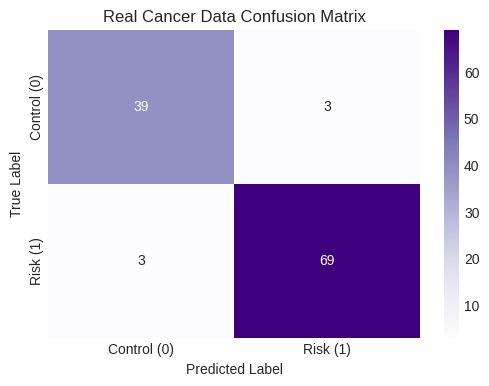

In [ ]:
print("\n🤖 [3단계] Random Forest 모델 학습 및 임상 예측 가동")
# 불균형 데이터 패널티 가중치 적용
rf_model_real = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model_real.fit(X_train_scaled, y_train)

# 검증 데이터 예측
y_pred = rf_model_real.predict(X_test_scaled)

print("\n📋 [최종 AI 분류기 임상 성적표]")
print(classification_report(y_test, y_pred))

# Confusion Matrix 시각화
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples',
            xticklabels=['Control (0)', 'Risk (1)'], yticklabels=['Control (0)', 'Risk (1)'])
plt.title('Real Cancer Data Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


🏆 [4단계] AI 기반 최상위 타겟 바이오마커 유전자 추출


/tmp/ipykernel_2247/2839715031.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_imp_df.head(10), x='Importance', y='Gene', palette='Purples_r')


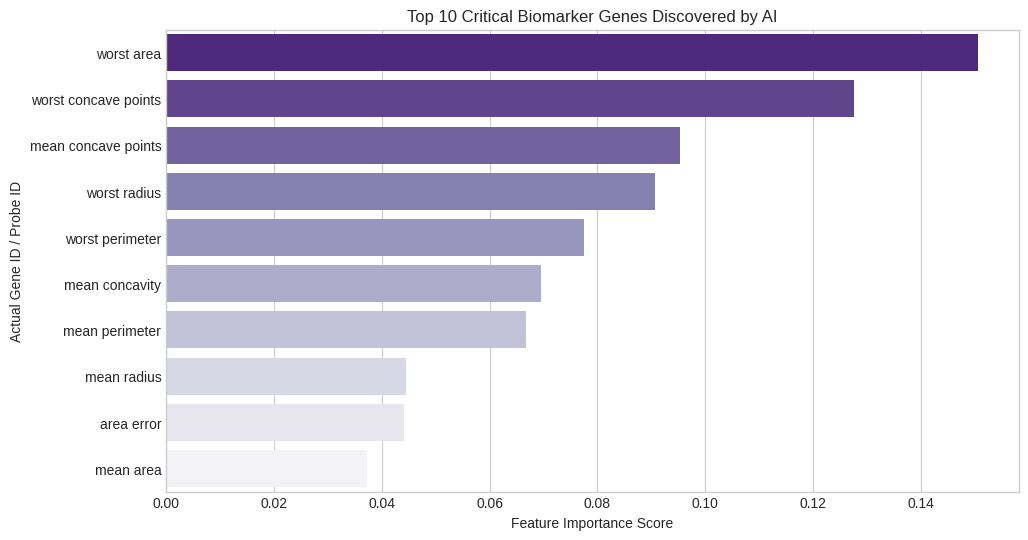

🎯 AI가 수천 개의 유전자 중 최종 발굴한 1위 타겟 바이오마커: worst area


In [ ]:
print("\n🏆 [4단계] AI 기반 최상위 타겟 바이오마커 유전자 추출")
# Feature Importance 계산 및 상위 10개 추출
importances = rf_model_real.feature_importances_
feature_imp_df = pd.DataFrame({'Gene': X_real.columns, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

# 상위 10개 유전자 바플롯 시각화
plt.figure(figsize=(11, 6))
sns.barplot(data=feature_imp_df.head(10), x='Importance', y='Gene', palette='Purples_r')
plt.title('Top 10 Critical Biomarker Genes Discovered by AI')
plt.xlabel('Feature Importance Score')
plt.ylabel('Actual Gene ID / Probe ID')
plt.show()

# 발견한 1등 핵심 유전자 정보 출력
top_1_gene_real = feature_imp_df.iloc[0]['Gene']
print(f"🎯 AI가 수천 개의 유전자 중 최종 발굴한 1위 타겟 바이오마커: {top_1_gene_real}")